# London Housing Price Growth Analysis

This notebook analyzes which London borough has experienced the greatest average increase in housing prices over the past two decades. 

The goal is to determine the borough with the highest growth and visualize the top 10 boroughs in terms of housing price increase.

In [ ]:
import pandas as pd
import matplotlib as plt

In [4]:
df = pd.read_csv("C:/Users/samee/Desktop/london_housing.csv")

In [8]:
df.head()

,Date,RegionName,AreaCode,AveragePrice,Index,IndexSA,1m%Change,12m%Change,AveragePriceSA,SalesVolume,...,NewPrice,NewIndex,New1m%Change,New12m%Change,NewSalesVolume,OldPrice,OldIndex,Old1m%Change,Old12m%Change,OldSalesVolume
0,01/01/2004,Aberdeenshire,S12000034,84638,41.1,NaN,NaN,NaN,NaN,388.0,...,112843.0,40.7,NaN,NaN,103.0,81273.0,41.0,NaN,NaN,285.0
1,01/02/2004,Aberdeenshire,S12000034,84623,41.1,NaN,0.0,NaN,NaN,326.0,...,113061.0,40.8,0.2,NaN,107.0,81194.0,40.9,-0.1,NaN,219.0
2,01/03/2004,Aberdeenshire,S12000034,86536,42.1,NaN,2.3,NaN,NaN,453.0,...,115218.0,41.6,1.9,NaN,140.0,83137.0,41.9,2.4,NaN,313.0
3,01/04/2004,Aberdeenshire,S12000034,87373,42.5,NaN,1.0,NaN,NaN,571.0,...,115247.0,41.6,0.0,NaN,180.0,84241.0,42.5,1.3,NaN,391.0
4,01/05/2004,Aberdeenshire,S12000034,89493,43.5,NaN,2.4,NaN,NaN,502.0,...,117377.0,42.4,1.8,NaN,167.0,86466.0,43.6,2.6,NaN,335.0


In [17]:
df.shape

(148050, 54)

In [18]:
df.columns

Index(['Date', 'RegionName', 'AreaCode', 'AveragePrice', 'Index', 'IndexSA',
       '1m%Change', '12m%Change', 'AveragePriceSA', 'SalesVolume',
       'DetachedPrice', 'DetachedIndex', 'Detached1m%Change',
       'Detached12m%Change', 'SemiDetachedPrice', 'SemiDetachedIndex',
       'SemiDetached1m%Change', 'SemiDetached12m%Change', 'TerracedPrice',
       'TerracedIndex', 'Terraced1m%Change', 'Terraced12m%Change', 'FlatPrice',
       'FlatIndex', 'Flat1m%Change', 'Flat12m%Change', 'CashPrice',
       'CashIndex', 'Cash1m%Change', 'Cash12m%Change', 'CashSalesVolume',
       'MortgagePrice', 'MortgageIndex', 'Mortgage1m%Change',
       'Mortgage12m%Change', 'MortgageSalesVolume', 'FTBPrice', 'FTBIndex',
       'FTB1m%Change', 'FTB12m%Change', 'FOOPrice', 'FOOIndex', 'FOO1m%Change',
       'FOO12m%Change', 'NewPrice', 'NewIndex', 'New1m%Change',
       'New12m%Change', 'NewSalesVolume', 'OldPrice', 'OldIndex',
       'Old1m%Change', 'Old12m%Change', 'OldSalesVolume'],
      dtype='object

In [39]:
df.info

<bound method DataFrame.info of                       RegionName  Year  AveragePrice
0                  Aberdeenshire  2004         84638
1                  Aberdeenshire  2004         84623
2                  Aberdeenshire  2004         86536
3                  Aberdeenshire  2004         87373
4                  Aberdeenshire  2004         89493
...                          ...   ...           ...
149485  Yorkshire and The Humber  2025        205946
149486  Yorkshire and The Humber  2025        206245
149487  Yorkshire and The Humber  2025        209601
149488  Yorkshire and The Humber  2025        207438
149489  Yorkshire and The Humber  2026        206470

[148050 rows x 3 columns]>

In [32]:
london_boroughs = [
    "Barking and Dagenham","Barnet","Bexley","Brent","Bromley","Camden",
    "City of London","Croydon","Ealing","Enfield","Greenwich","Hackney",
    "Hammersmith and Fulham","Haringey","Harrow","Havering","Hillingdon",
    "Hounslow","Islington","Kensington and Chelsea","Kingston upon Thames",
    "Lambeth","Lewisham","Merton","Newham","Redbridge","Richmond upon Thames",
    "Southwark","Sutton","Tower Hamlets","Waltham Forest","Wandsworth","Westminster"
]

In [48]:
df_london = df[df["RegionName"].isin(london_boroughs)]
df_london.head()

,RegionName,Year,AveragePrice
3792,Barking and Dagenham,1995,51870
3793,Barking and Dagenham,1995,52513
3794,Barking and Dagenham,1995,52701
3795,Barking and Dagenham,1995,54618
3796,Barking and Dagenham,1995,54524


In [46]:
df_yearly = df_london.groupby(["RegionName", "Year"])["AveragePrice"].mean().reset_index()
df_yearly.head()

,RegionName,Year,AveragePrice
0,Barking and Dagenham,1995,53265.416667
1,Barking and Dagenham,1996,53162.666667
2,Barking and Dagenham,1997,57537.583333
3,Barking and Dagenham,1998,61969.666667
4,Barking and Dagenham,1999,67145.333333


In [47]:
growth_list = []

for borough in df_yearly["RegionName"].unique():
    temp = df_yearly[df_yearly["RegionName"] == borough].sort_values("Year")
    start_price = temp["AveragePrice"].iloc[0]
    end_price = temp["AveragePrice"].iloc[-1]
    growth = (end_price - start_price) / start_price
    growth_list.append([borough, growth])

growth_df = pd.DataFrame(growth_list, columns=["Borough", "Growth"])
growth_df = growth_df.sort_values(by="Growth", ascending=False)
growth_df["GrowthPercent"] = growth_df["Growth"] * 100
growth_df.head(10)

,Borough,Growth,GrowthPercent
11,Hackney,8.114772,811.477203
30,Waltham Forest,7.263735,726.373482
22,Lewisham,6.979099,697.909857
27,Southwark,6.936354,693.635435
6,City of London,6.529434,652.943440
21,Lambeth,6.492503,649.250255
13,Haringey,6.401307,640.130725
18,Islington,6.321293,632.129348
25,Redbridge,6.258224,625.822424
10,Greenwich,6.139897,613.989691


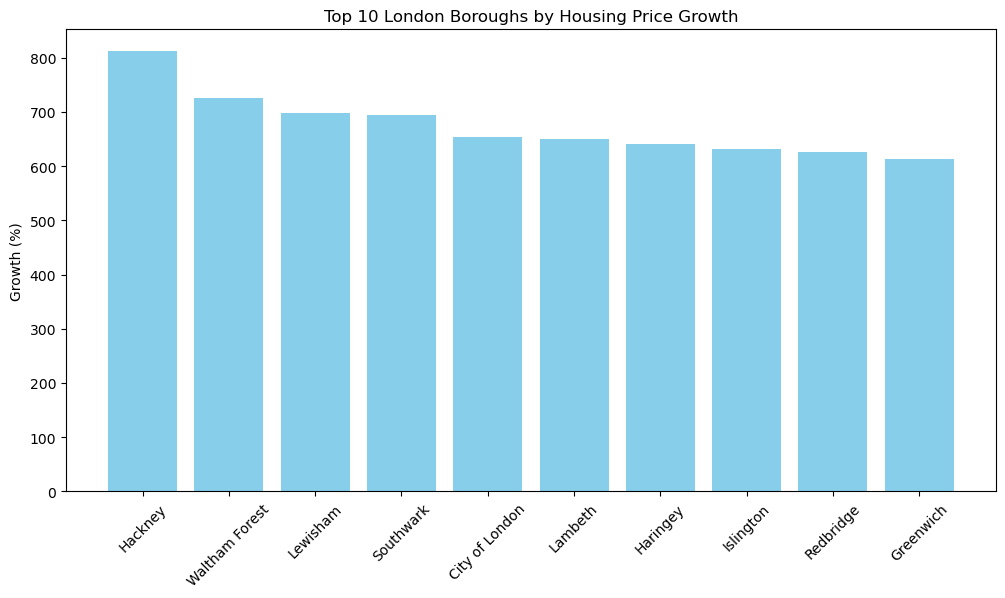

In [49]:
top10 = growth_df.head(10)

plt.figure(figsize=(12,6))
plt.bar(top10["Borough"], top10["GrowthPercent"], color='skyblue')
plt.xticks(rotation=45)
plt.ylabel("Growth (%)")
plt.title("Top 10 London Boroughs by Housing Price Growth")
plt.show()

**Conclusion:**

Based on the analysis, **Hackney** has experienced the greatest average increase in housing prices over the past two decades, with an approximate growth of **811%**. Other high-growth boroughs include Waltham Forest (726%) and Lewisham (698%). 

This indicates that housing prices in certain London boroughs have risen significantly faster than in others, likely due to factors such as gentrification, infrastructure improvements, and high demand.

# Methodology

1. **Loaded the Dataset**: Imported the CSV file containing London housing prices and inspected the data structure to understand available columns.

2. **Filtered for London Boroughs**: Selected only the 32 official London boroughs to focus the analysis on relevant areas.

3. **Used Existing Year Column**: The dataset already included a 'Year' column, so date conversion was not needed.

4. **Grouped by Borough and Year**: Calculated the average house price for each borough for every year in the dataset.

5. **Calculated Growth per Borough**: Computed the growth percentage for each borough as:  
   \[
   \text{Growth} = \frac{\text{Price}_{\text{last year}} - \text{Price}_{\text{first year}}}{\text{Price}_{\text{first year}}} \times 100
   \]

6. **Sorted and Identified Top Boroughs**: Ranked boroughs by growth percentage and identified the top 10 boroughs with the highest price increase.

7. **Visualized Results**: Created a bar chart to display the top 10 boroughs by housing price growth for clear comparison.